<div align="center" style=" font-size: 80%; text-align: center; margin: 0 auto">
<img src="https://raw.githubusercontent.com/Explore-AI/Pictures/master/Python-Notebook-Banners/Code_challenge.png"  style="display: block; margin-left: auto; margin-right: auto;";/>
</div>


## Image classification MCQ 
© ExploreAI Academy

The versatile machine learning techniques you have been learning will enable you to process complex and different data at a faster pace.  

So far you have performed classification on both tabular  ([iris dataset](https://scikit-learn.org/stable/auto_examples/datasets/plot_iris_dataset.html)) and textual data ([the mbti dataset](https://www.kaggle.com/datasnaek/mbti-type)). In this notebook, you will apply the machine learning techniques you have learned for image classification. 

## Imports

Let's go ahead and load our libraries

In [112]:
import numpy as np
import gzip # This is used in extracting the images

import matplotlib.pyplot as plt # In order to plot the images to see what we are dealing with
from sklearn.ensemble import RandomForestClassifier # You'll be using Random Forest to classify the images
from sklearn.metrics import accuracy_score # Sklearn's way of measuring accuracy
from sklearn.metrics import classification_report 


# The data

The dataset we will be using is called `MNIST`. This is a large collection of hand-drawn digits `0 to 9` and is a good dataset to learn image classification on as it requires little to no preprocessing.

The dataset can be downloaded from [The MNIST Database](https://web.archive.org/web/20220331130319/https://yann.lecun.com/exdb/mnist/). Download all four files. These files are the images and their respective labels (normally, we're required to split the x (image data / characteristics) and y (labels) out during preprocessing, but this has already been done for us). The dataset has also already been split into a train and a test set.

Once you've downloaded the data, make sure that the data are in the same folder as this Jupyter notebook. If you've managed to do all that, we can now begin! 

By default, the MNIST files are compressed in the gzip format. The following two functions will extract the data for you. ** **Don't change this code.** **

In [113]:
import gzip
import numpy as np
import cv2  # Used to resize images from 28x28 to 224x224

def extract_data(filename, num_images, IMAGE_WIDTH):
    """Extract the images into a 2D tensor and resize to IMAGE_WIDTH."""
    NATIVE_WIDTH = 28 # MNIST original dimension
    
    with gzip.open(filename) as bytestream:
        bytestream.read(16) # Skip header
        # 1. Read bytes matching the true native database dimensions
        buf = bytestream.read(NATIVE_WIDTH * NATIVE_WIDTH * num_images)
        data = np.frombuffer(buf, dtype=np.uint8)
        
        # 2. Reshape into individual 28x28 matrices
        data = data.reshape(num_images, NATIVE_WIDTH, NATIVE_WIDTH)
        
        # 3. If target width matches native, just flatten and return
        if IMAGE_WIDTH == NATIVE_WIDTH:
            return data.reshape(num_images, NATIVE_WIDTH * NATIVE_WIDTH).astype(np.float32)
        
        # 4. If target width is different (e.g. 224), resize each image
        resized_data = np.empty((num_images, IMAGE_WIDTH * IMAGE_WIDTH), dtype=np.float32)
        for i in range(num_images):
            resized_img = cv2.resize(data[i], (IMAGE_WIDTH, IMAGE_WIDTH), interpolation=cv2.INTER_LINEAR)
            resized_data[i] = resized_img.flatten()
            
        return resized_data

def extract_labels(filename, num_images):
    """Extract the labels into a vector of int64 label IDs."""
    with gzip.open(filename) as bytestream:
        bytestream.read(8) # Skip header
        buf = bytestream.read(1 * num_images)
        labels = np.frombuffer(buf, dtype=np.uint8).astype(np.int64)
    return labels


## Challenge 1: Extracting the data

The MNIST dataset consists of 60,000 training images and 10,000 testing images. This is a lot of data! Let's not extract all of that right now. Create a function `get_data` that uses the above functions to extract a certain number of images and their labels from the gzip files.

The function will take as input two integer values, the number of train and test images to be extracted. Let's extract `5000` train images and `1000` test images. The function then returns four variables in the form of `(X_train, y_train), (X_test, y_test)`, where `(X_train, y_train)` are the extracted images and labels of the training set, and `(X-test, y_test)` are the extracted images and labels of the testing set. (Hint – you'll have to use the functions provided more than once.) 

Image pixel values range from 0 to 255. We need to normalise the image pixels so that they are in the range 0 to 1.

_**Function specifications:**_
* Should take two integers as input, one representing the number of training images and the other the number of testing images.
* Should return two `tuples` of the form `(X_train, y_train), (X_test, y_test)`.

_**Note**_ that the size of the MNIST images is 28x28.

Usually when setting up your dataset, it is a good idea to randomly shuffle your data in case your data are ordered. Think of this as shuffling a pack of cards. Here, however, we aren't going to shuffle the data so that all our answers are the same.

In [114]:
### START FUNCTION

def get_data(num_train_images, num_test_images):
    """ 
    This function extracts the training and testing data from the MNIST dataset and normalizes it to be between 0 and 1.
    utilizing the extract_data and extract_labels functions.
    args:
        num_train_images: number of training images to extract
        num_test_images: number of testing images to address
    returns:
        (X_train, y_train): tuple of training data and labels
        (X_test, y_test): tuple of testing data and labels
    """
    # Appended .gz to all four path targets to support gzip.open
    train_img_path = "C:\\Users\\Anthony\\Pictures\\alX-datascience\\machine_learning\\notebooks\\week8\\train-images-idx3-ubyte.gz"
    train_labels_path = "C:\\Users\\Anthony\\Pictures\\alX-datascience\\machine_learning\\notebooks\\week8\\train-labels-idx1-ubyte.gz"
    test_img_path = "C:\\Users\\Anthony\\Pictures\\alX-datascience\\machine_learning\\notebooks\\week8\\t10k-images-idx3-ubyte.gz"
    test_labels_path =  "C:\\Users\\Anthony\\Pictures\\alX-datascience\\machine_learning\\notebooks\\week8\\t10k-labels-idx1-ubyte.gz"
    
    img_width = 28
    
    # 2. Extract training data and labels using the training file paths
    X_train = extract_data(train_img_path, num_train_images, img_width)
    y_train = extract_labels(train_labels_path, num_train_images)
    
    # 3. Extract testing data and labels using the testing file paths
    X_test = extract_data(test_img_path, num_test_images, img_width)
    y_test = extract_labels(test_labels_path, num_test_images)
    
    # 4. Normalize the pixel values to be between 0 and 1
    X_train = X_train.astype('float32') / 255.0
    X_test = X_test.astype('float32') / 255.0
    
    return (X_train, y_train), (X_test, y_test)

### END FUNCTION

In [115]:
(X_train, y_train), (X_test, y_test) = get_data(5000, 1000)

In [116]:
X_train.shape

(5000, 784)

In [117]:
X_test.shape

(1000, 784)

In [118]:
X_train[1, 349]

np.float32(0.10980392)

In [119]:
y_test[50]

np.int64(6)

## Plotting the data

Let's see what this data looks like! Right now the images are "flattened" into a 1-D array of length 784. In order to plot the image we first need to reshape it to the correct size of 28x28. We'll print out the respective label to make sure we are plotting the right number.

Label:  0


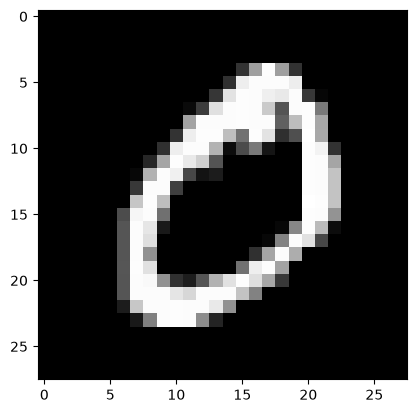

In [120]:
image_index = 1 ## Change me to view different images

print("Label: ", y_train[image_index])
reshaped_image = X_train[image_index].reshape((28, 28))

plt.imshow(reshaped_image, cmap='gray')
plt.show()

## Challenge 2: Training the model

Now that we have formatted our data, we can fit a model using sklearn's `RandomForestClassifier` class with `20 estimators` and its `random_state` set to `42`. We'll write a function that will take as input the image and label variables that we created previously, and return a trained model.

_**Function specifications:**_
* Should take two NumPy `arrays` as input in the form `(X_train, y_train)`.
* Should return an sklearn `RandomForestClassifier` model which has a random state of 42 and number of estimators 20.
* The returned model should be fitted to the data.

In [121]:
### START FUNCTION
def train_model(X_train, y_train):
    """
    Using Randoforest to train the model
    """
    rf_model = RandomForestClassifier(
    # --- Ensemble Layout & Size ---
    n_estimators=20,            # Number of trees in the forest
    bootstrap=True,              # Whether bootstrap samples are used when building trees
    oob_score=False,             # Whether to use out-of-bag samples to estimate generalization score
    
    # --- Tree Splitting Control ---
    criterion='gini',            # Split quality metric ('gini', 'entropy', 'log_loss')
    max_depth=None,              # Maximum depth of the tree (None = grows until pure)
    min_samples_split=2,         # Minimum samples required to split an internal node
    min_samples_leaf=1,          # Minimum samples required to be at a leaf node
    min_weight_fraction_leaf=0.0,# Minimum weighted fraction of sum total of weights required at a leaf
    max_features='sqrt',         # Number of features to consider when looking for best split ('sqrt', 'log2', None, int, float)
    max_leaf_nodes=None,         # Grow trees with max_leaf_nodes in best-first fashion
    min_impurity_decrease=0.0,   # Split node if split induces impurity decrease >= this value
    
    # --- Randomness & Weights ---
    class_weight=None,           # Weights associated with classes ('balanced', 'balanced_subsample', dict)
    ccp_alpha=0.0,               # Complexity parameter used for Minimal Cost-Complexity Pruning
    max_samples=None,            # If bootstrap is True, number of samples to draw from X to train each base estimator
    random_state=42,             # Controls randomness of bootstrapping and feature selection
    
    # --- System & Output Control ---
    n_jobs=-1,                   # Number of jobs to run in parallel (-1 uses all processors)
    verbose=0,                   # Controls verbosity when fitting and predicting
    warm_start=False             # Reuse solution of previous call to fit and add more estimators
    )

    rf_model.fit(X_train, y_train)

    return rf_model

### END FUNCTION

In [122]:
clf = train_model(X_train, y_train)

## Challenge 3: Testing the model

Now that you have trained your model, let's see how well it does on the test set. Write a function which returns the accuracy of our trained model when tested with the test set.

_**Function specifications:**_
* Should take the fitted model `clf` and two NumPy arrays `X_test, y_test` as input.
* Should return a `float` of the accuracy of the model. This number should be between zero and one.

In [123]:
### START FUNCTION
def calculate_accuracy(clf, X_test, y_test):
    """ 
    Model Metrics
    """
    y_pred = clf.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)
    return accuracy

### END FUNCTION

In [124]:
print(calculate_accuracy(clf,X_test,y_test))

0.891


Classification reports give us more information on where our model is going wrong – looking specifically at the performance caused by Type I and II errors. Write a function that returns the classification report of your test set.

_**Function specifications:**_
* Should take the fitted model `clf` and two NumPy arrays `X_test, y_test` as input.
* Should return a classification report.

In [125]:
### START FUNCTION
def get_class_report(clf, X_test, y_test):
    """ 
    Classification Report metrics
    """
    y_pred = clf.predict(X_test)

    clr = classification_report(y_test, y_pred)
    return clr

### END FUNCTION

In [126]:
print(get_class_report(clf,X_test,y_test))

              precision    recall  f1-score   support

           0       0.94      0.99      0.97        85
           1       0.98      0.98      0.98       126
           2       0.88      0.90      0.89       116
           3       0.84      0.83      0.84       107
           4       0.86      0.90      0.88       110
           5       0.86      0.85      0.86        87
           6       0.91      0.93      0.92        87
           7       0.88      0.85      0.87        99
           8       0.93      0.78      0.85        89
           9       0.81      0.88      0.85        94

    accuracy                           0.89      1000
   macro avg       0.89      0.89      0.89      1000
weighted avg       0.89      0.89      0.89      1000



## Plotting the results

Let's actually see if our model has trained correctly. To do so, plot some of the images with their predicted labels. Since we don't have the predictions stored in our notebook's memory, we need to call the predict function here first.

Predicted Label:  7


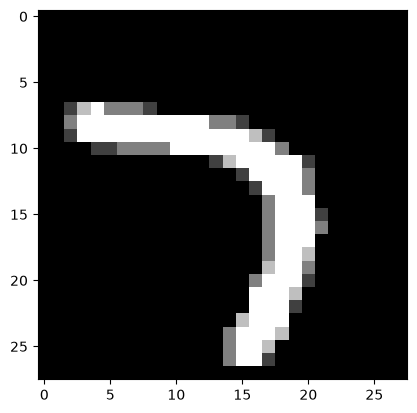

In [130]:
preds = clf.predict(X_test)

image_index = 60 ## Change me to see other predictions

print("Predicted Label: ",preds[image_index])
plt.imshow(X_test[image_index].reshape((28, 28)), cmap='gray')
plt.show()

Since we didn't use all the data in the beginning, there is a chance our performance can improve. Go change the amount of data we use to see how it affects the accuracy of your model.

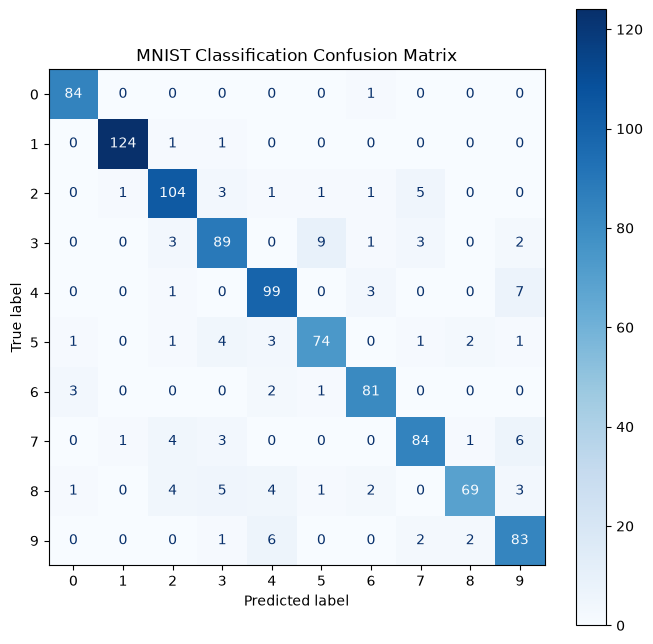

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# 1. Generate the raw confusion matrix
cm = confusion_matrix(y_test, preds)

# 2. Refine it into a clear, labeled visual plot
# For MNIST, standard display labels would be strings of digits 0-9
display_labels = [str(i) for i in range(10)] 

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=display_labels)

# 3. Render the plot with a clean color map
fig, ax = plt.subplots(figsize=(8, 8)) # Give it room so numbers don't overlap
disp.plot(cmap=plt.cm.Blues, ax=ax, values_format='d') # 'd' ensures integers display, not scientific notation

plt.title("MNIST Classification Confusion Matrix")
plt.show()

#  

<div align="center" style=" font-size: 80%; text-align: center; margin: 0 auto">
<img src="https://raw.githubusercontent.com/Explore-AI/Pictures/master/ExploreAI_logos/EAI_Blue_Dark.png"  style="width:200px";/>
</div>